# 02 — Ingeniería de Variables

> **Proyecto**: Optimización de Portafolios con ML — Tecnológico de Monterrey, AD2026  
> **Etapa**: 02 / 09 — Feature Engineering  
> **Módulo**: `src/features/technical_indicators.py`

## Objetivos

1. Construir el dataset de features técnicas y de momentum sobre los **40 representantes** del universo analizable.
2. Validar la calidad estadística de cada feature (completitud, distribución, correlación con retornos futuros).
3. Guardar el dataset procesado en `data/processed/features.parquet` para uso en notebooks posteriores.

## Features construidas

| Grupo | Features |
|-------|----------|
| Retornos | `log_ret_1d`, `log_ret_5d`, `log_ret_21d`, `log_ret_63d` |
| Momentum | `mom_1m`, `mom_3m`, `mom_6m`, `mom_12m` |
| Volatilidad | `vol_21d`, `vol_63d`, `sharpe_63d` |
| Riesgo | `beta_63d` (β vs SPY) |
| Técnicos | `rsi_14`, `rsi_21`, `macd`, `macd_signal`, `macd_hist` |
| Técnicos | `bb_pct`, `ema_ratio_20_50`, `ema_ratio_50_200` |
| Cross-sectional | `zscore_ret_1d`, `zscore_mom_3m` |

---
## 0. Configuración

In [2]:
import sys, os
# ── Asegurar que src/ está en el path ─────────────────────────────────────────
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from src.features.technical_indicators import (
    FeatureEngineer,
    build_features,
    load_prices,
    ALL_REPRES,
    REPRES,
    BENCHMARK,
)

# ── Estética ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'sans-serif',
})

PALETTE = {
    'Information Technology': '#4C9BE8',
    'Consumer Staples':       '#2ECC71',
    'Health Care':            '#E74C3C',
    'Consumer Discretionary': '#F39C12',
    'SPY / Benchmark':        '#95A5A6',
}

# ── Rutas ─────────────────────────────────────────────────────────────────────
CSV_PATH        = '../data/datos.csv'
FEATURES_PATH   = '../data/processed/features.parquet'
PRICES_PATH     = '../data/processed/prices_repr.parquet'

print('✓ Configuración lista')
print(f'  Universo representativo: {len(ALL_REPRES)} activos (40 + SPY)')

✓ Configuración lista
  Universo representativo: 41 activos (40 + SPY)


---
## 1. Carga de Precios

In [3]:
# ── Carga y construcción del índice temporal ───────────────────────────────────
prices = load_prices(CSV_PATH, tickers=ALL_REPRES)

print(f'Dimensiones del dataset de precios : {prices.shape}')
print(f'Período                            : {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Tickers cargados                   : {len(prices.columns)}')
print(f'Missing values totales             : {prices.isna().sum().sum()}')
print()

# Verificar disponibilidad por sector
sector_lookup = {t: s for s, tickers in REPRES.items() for t in tickers}
for sector, tickers in REPRES.items():
    available = [t for t in tickers if t in prices.columns]
    print(f'  {sector:<30}: {len(available):>2}/{len(tickers)} disponibles  {available}')

Dimensiones del dataset de precios : (2660, 41)
Período                            : 2015-01-02 → 2025-03-13
Tickers cargados                   : 41
Missing values totales             : 0

  Information Technology        : 10/10 disponibles  ['AAPL', 'MSFT', 'NVDA', 'AVGO', 'CSCO', 'CRM', 'AMD', 'QCOM', 'TXN', 'NOW']
  Consumer Staples              : 10/10 disponibles  ['PG', 'KO', 'PEP', 'WMT', 'COST', 'MO', 'PM', 'CL', 'GIS', 'HRL']
  Health Care                   : 10/10 disponibles  ['JNJ', 'MRK', 'LLY', 'ABBV', 'PFE', 'ABT', 'AMGN', 'ISRG', 'UNH', 'MDT']
  Consumer Discretionary        : 10/10 disponibles  ['AMZN', 'TSLA', 'HD', 'MCD', 'NKE', 'SBUX', 'BKNG', 'RCL', 'LOW', 'TJX']


---
## 2. Cálculo de Features

In [4]:

# ── Inicializar FeatureEngineer y calcular todas las features ──────────────────
fe = FeatureEngineer(prices, benchmark=BENCHMARK)
features = fe.compute_all(tickers_subset=ALL_REPRES)

# Eliminar las primeras 252 filas (warm-up de indicadores de largo plazo)
features_clean = features.iloc[252:].copy()
prices_clean   = prices.iloc[252:].copy()

print(f'Features totales calculadas    : {features.shape}')
print(f'Features (post warm-up 252d)   : {features_clean.shape}')
print(f'Feature groups disponibles     : {features_clean.columns.get_level_values(0).unique().tolist()}')
print(f'Período efectivo de análisis   : {features_clean.index[0].date()} → {features_clean.index[-1].date()}')

Features totales calculadas    : (2660, 902)
Features (post warm-up 252d)   : (2408, 902)
Feature groups disponibles     : ['log_ret_1d', 'log_ret_5d', 'log_ret_21d', 'log_ret_63d', 'mom_1m', 'mom_3m', 'mom_6m', 'mom_12m', 'vol_21d', 'vol_63d', 'beta_63d', 'sharpe_63d', 'rsi_14', 'rsi_21', 'macd', 'macd_signal', 'macd_hist', 'bb_pct', 'ema_ratio_20_50', 'ema_ratio_50_200', 'zscore_ret_1d', 'zscore_mom_3m']
Período efectivo de análisis   : 2015-12-22 → 2025-03-13


In [5]:
# ── Completitud por feature group ─────────────────────────────────────────────
completeness = (
    features_clean
    .notna()
    .groupby(level=0, axis=1)
    .mean()
    .mean()
    .rename('completitud_%')
    .mul(100)
    .round(2)
)
print('Completitud promedio por grupo de features:')
print(completeness.to_string())

Completitud promedio por grupo de features:
bb_pct              100.0
beta_63d            100.0
ema_ratio_20_50     100.0
ema_ratio_50_200    100.0
log_ret_1d          100.0
log_ret_21d         100.0
log_ret_5d          100.0
log_ret_63d         100.0
macd                100.0
macd_hist           100.0
macd_signal         100.0
mom_12m             100.0
mom_1m              100.0
mom_3m              100.0
mom_6m              100.0
rsi_14              100.0
rsi_21              100.0
sharpe_63d          100.0
vol_21d             100.0
vol_63d             100.0
zscore_mom_3m       100.0
zscore_ret_1d       100.0


---
## 3. Exploración de Features por Activo Representativo

Visualizamos las features clave para NVDA (IT), COST (Consumer Staples), LLY (Health Care) y AMZN (Consumer Discretionary).

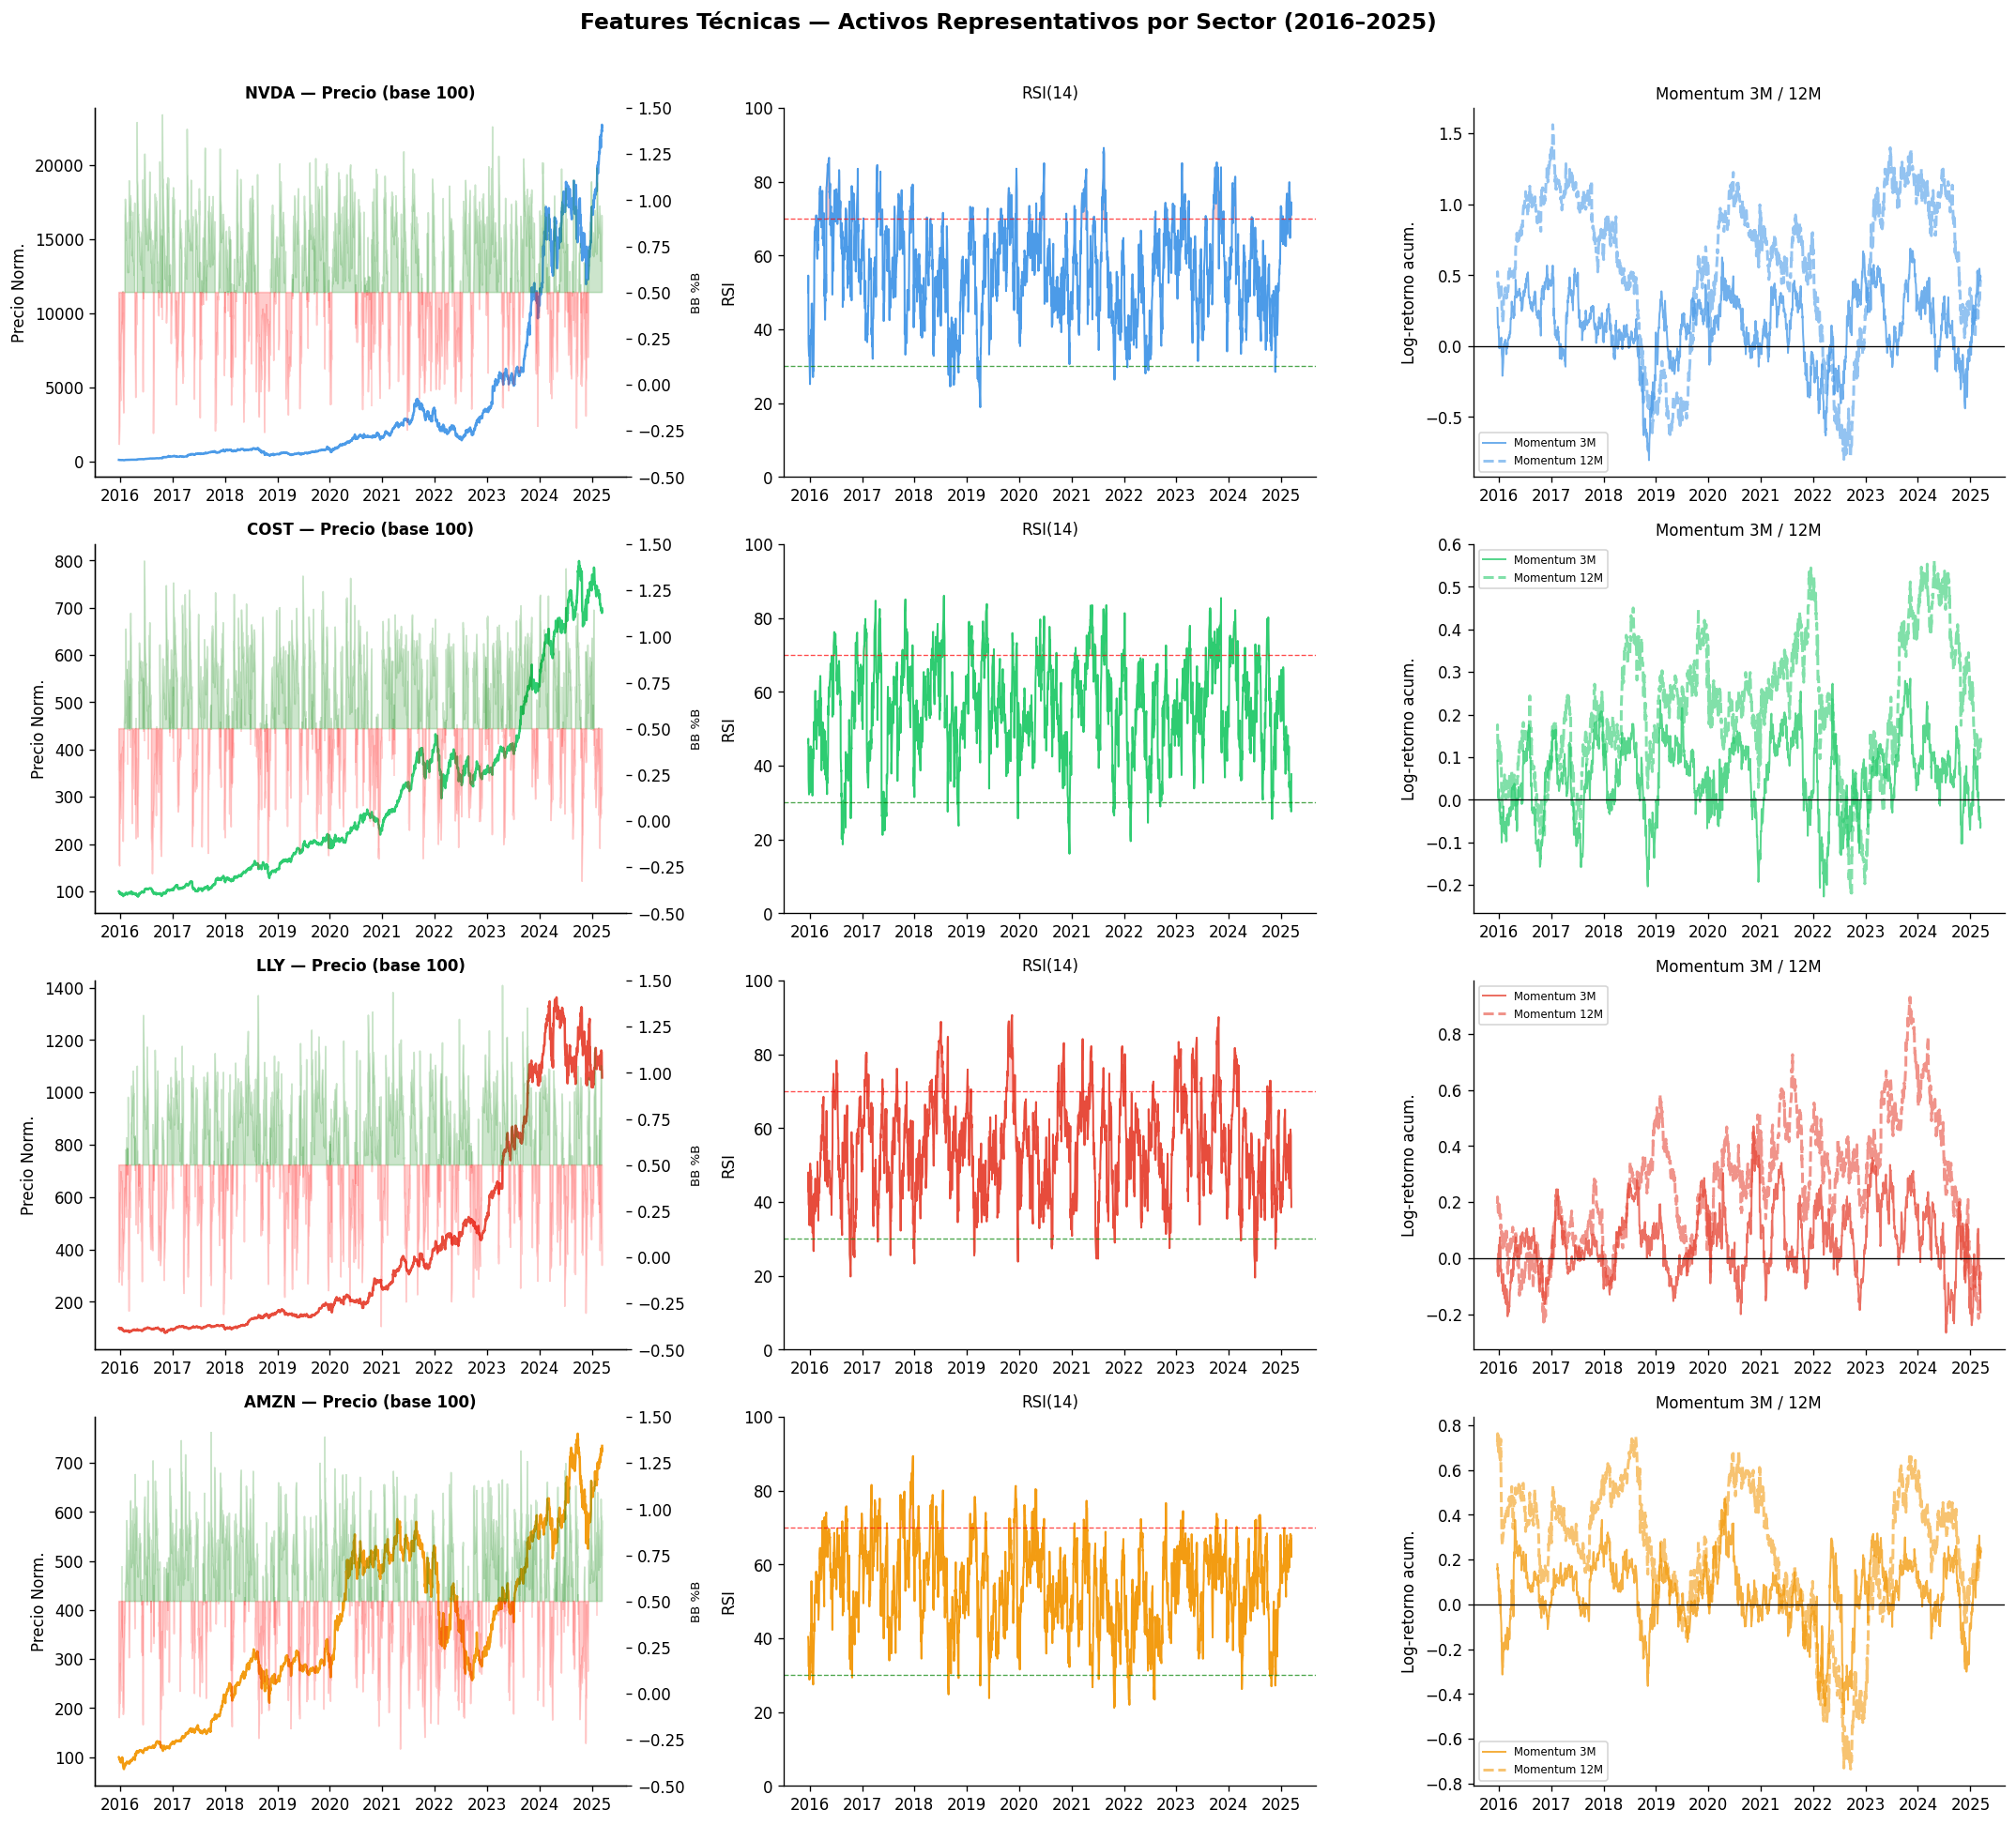

In [6]:
# ── Panel de features para 4 activos representativos ──────────────────────────
SAMPLE_TICKERS = {
    'NVDA': 'Information Technology',
    'COST': 'Consumer Staples',
    'LLY':  'Health Care',
    'AMZN': 'Consumer Discretionary',
}

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
fig.suptitle('Features Técnicas — Activos Representativos por Sector (2016–2025)',
             fontsize=14, fontweight='bold', y=1.01)

for row_idx, (ticker, sector) in enumerate(SAMPLE_TICKERS.items()):
    color = PALETTE.get(sector, '#888888')
    tf = fe.compute_for_ticker(ticker).iloc[252:]
    p_norm = prices_clean[ticker] / prices_clean[ticker].iloc[0] * 100

    # Col 0: Precio normalizado + Bollinger %B
    ax0 = axes[row_idx, 0]
    ax0.plot(p_norm.index, p_norm, color=color, lw=1.5, label=ticker)
    ax0.set_title(f'{ticker} — Precio (base 100)', fontsize=10, fontweight='bold')
    ax0.set_ylabel('Precio Norm.')
    ax0_twin = ax0.twinx()
    ax0_twin.fill_between(tf.index, tf['bb_pct'], 0.5,
                          where=(tf['bb_pct'] > 0.5), alpha=0.2, color='green', label='BB %B > 0.5')
    ax0_twin.fill_between(tf.index, tf['bb_pct'], 0.5,
                          where=(tf['bb_pct'] < 0.5), alpha=0.2, color='red')
    ax0_twin.set_ylim(-0.5, 1.5)
    ax0_twin.set_ylabel('BB %B', fontsize=8)

    # Col 1: RSI(14)
    ax1 = axes[row_idx, 1]
    ax1.plot(tf.index, tf['rsi_14'], color=color, lw=1.2)
    ax1.axhline(70, color='red', ls='--', lw=0.8, alpha=0.7)
    ax1.axhline(30, color='green', ls='--', lw=0.8, alpha=0.7)
    ax1.fill_between(tf.index, tf['rsi_14'], 70, where=(tf['rsi_14'] > 70), alpha=0.2, color='red')
    ax1.fill_between(tf.index, tf['rsi_14'], 30, where=(tf['rsi_14'] < 30), alpha=0.2, color='green')
    ax1.set_ylim(0, 100)
    ax1.set_title('RSI(14)', fontsize=10)
    ax1.set_ylabel('RSI')

    # Col 2: Momentum y Sharpe rolling
    ax2 = axes[row_idx, 2]
    ax2.plot(tf.index, tf['mom_3m'], color=color, lw=1.2, label='Momentum 3M', alpha=0.8)
    ax2.plot(tf.index, tf['mom_12m'], color=color, lw=1.8, ls='--', label='Momentum 12M', alpha=0.6)
    ax2.axhline(0, color='black', lw=0.8)
    ax2.set_title('Momentum 3M / 12M', fontsize=10)
    ax2.set_ylabel('Log-retorno acum.')
    ax2.legend(fontsize=7)

plt.tight_layout()
plt.show()

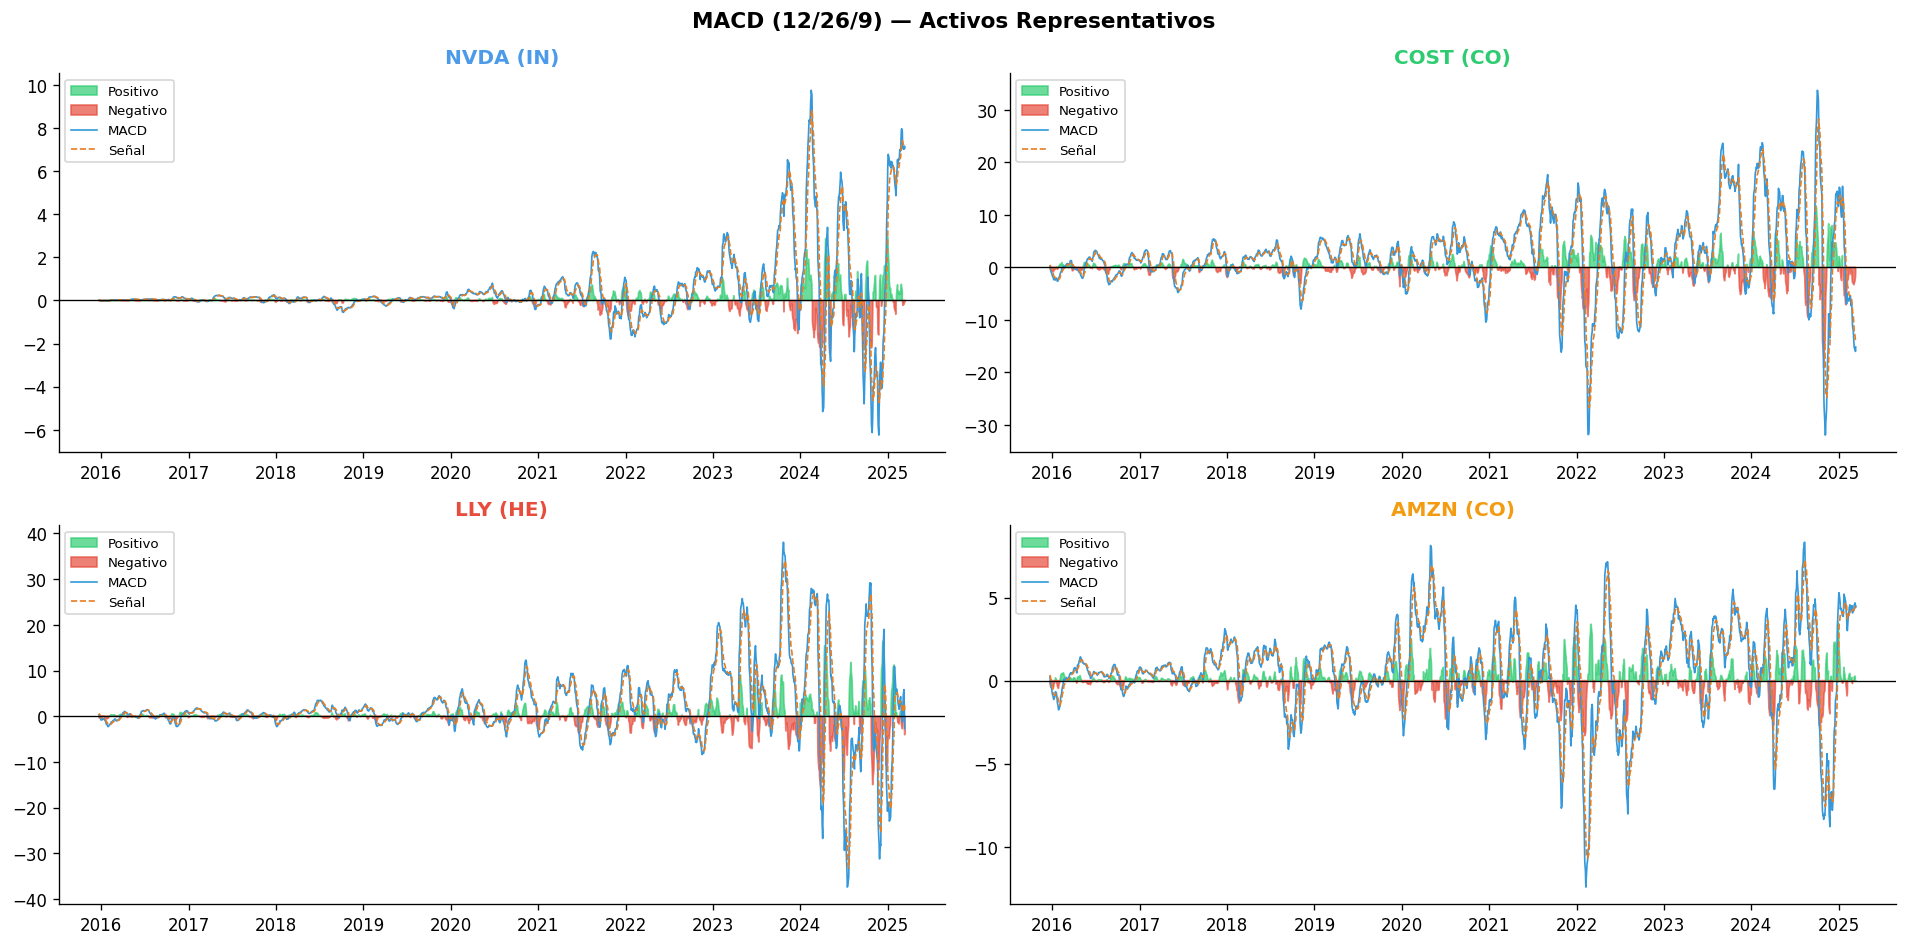

In [7]:
# ── MACD — histograma para los 4 activos ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('MACD (12/26/9) — Activos Representativos', fontsize=13, fontweight='bold')

for ax, (ticker, sector) in zip(axes.flatten(), SAMPLE_TICKERS.items()):
    color = PALETTE.get(sector, '#888888')
    tf = fe.compute_for_ticker(ticker).iloc[252:]

    # Área MACD histograma
    hist = tf['macd_hist']
    ax.fill_between(hist.index, hist, 0,
                    where=(hist >= 0), color='#2ECC71', alpha=0.7, label='Positivo')
    ax.fill_between(hist.index, hist, 0,
                    where=(hist < 0),  color='#E74C3C', alpha=0.7, label='Negativo')
    ax.plot(tf.index, tf['macd'],        color='#3498DB', lw=1.0, label='MACD')
    ax.plot(tf.index, tf['macd_signal'], color='#E67E22', lw=1.0, ls='--', label='Señal')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{ticker} ({sector[:2].upper()})', fontweight='bold', color=color)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 4. Distribución de Features por Sector

Comparamos la distribución de las features clave entre los 4 sectores GICS.

In [8]:
# ── Distribución cross-sectional de vol_21d, sharpe_63d, beta_63d ─────────────
FEATURES_SECTOR = ['vol_21d', 'sharpe_63d', 'beta_63d', 'mom_3m']
FEATURE_LABELS  = ['Volatilidad 21d (anual.)', 'Sharpe 63d', 'Beta vs SPY 63d', 'Momentum 3M']

# Construir DataFrame largo: feature | valor | sector | ticker
rows = []
for sector, tickers in REPRES.items():
    for ticker in tickers:
        if ticker not in prices.columns:
            continue
        tf = fe.compute_for_ticker(ticker).iloc[252:]
        for feat in FEATURES_SECTOR:
            if feat in tf.columns:
                for val in tf[feat].dropna():
                    rows.append({'feature': feat, 'valor': val,
                                 'sector': sector, 'ticker': ticker})

df_long = pd.DataFrame(rows)
print(f'Registros construidos: {len(df_long):,}')

Registros construidos: 385,280


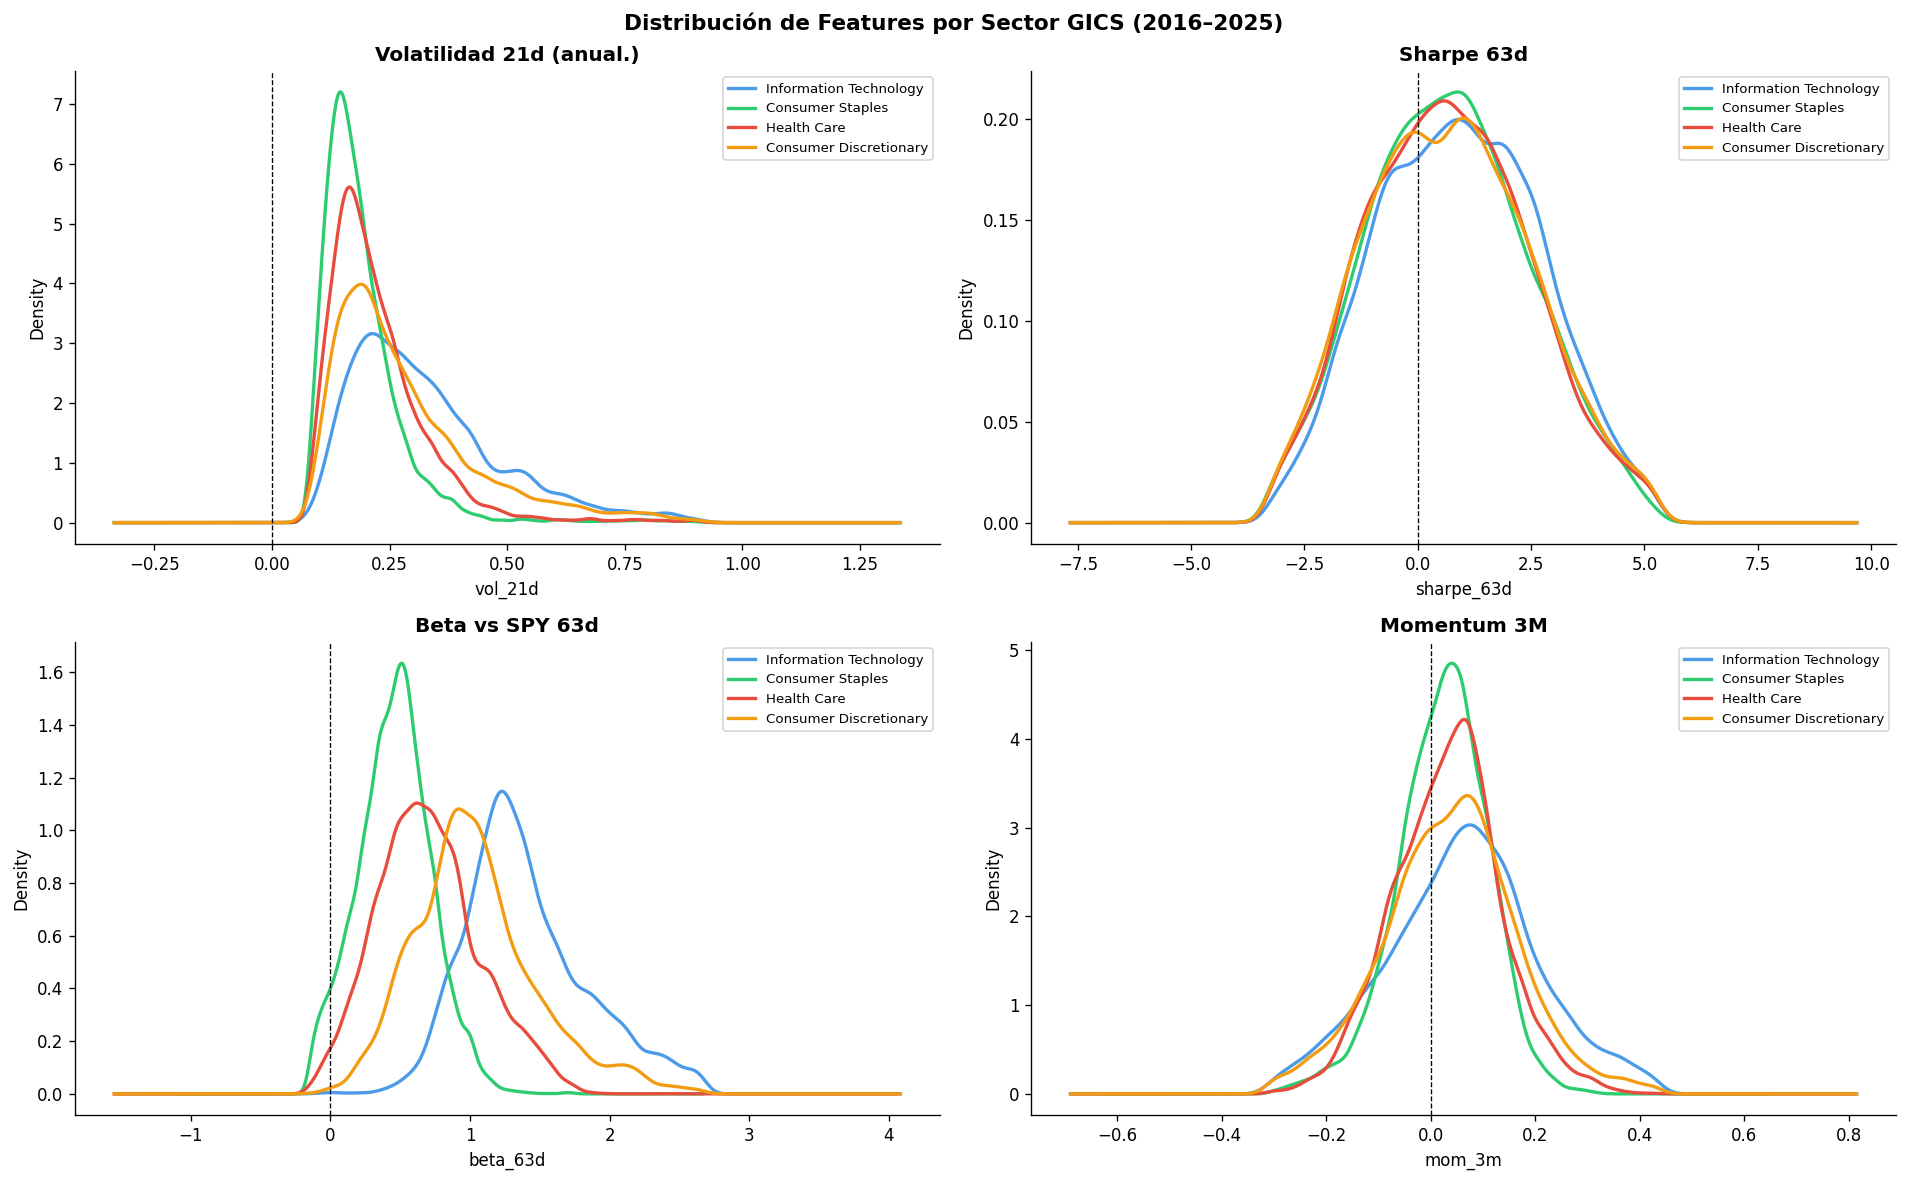

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribución de Features por Sector GICS (2016–2025)',
             fontsize=13, fontweight='bold')

for ax, (feat, label) in zip(axes.flatten(), zip(FEATURES_SECTOR, FEATURE_LABELS)):
    df_feat = df_long[df_long['feature'] == feat]
    # Percentil 1-99 para cortar outliers
    q1, q99 = df_feat['valor'].quantile(0.01), df_feat['valor'].quantile(0.99)
    df_feat_clip = df_feat[(df_feat['valor'] >= q1) & (df_feat['valor'] <= q99)]

    for sector in REPRES:
        vals = df_feat_clip[df_feat_clip['sector'] == sector]['valor']
        vals.plot.kde(ax=ax, label=sector, color=PALETTE[sector], lw=2)

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(feat)
    ax.legend(fontsize=8)
    ax.axvline(0, color='black', lw=0.8, ls='--')

plt.tight_layout()
plt.show()

---
## 5. Heatmap de Correlación entre Features

Usamos NVDA como caso de estudio para ver la correlación entre las features calculadas.

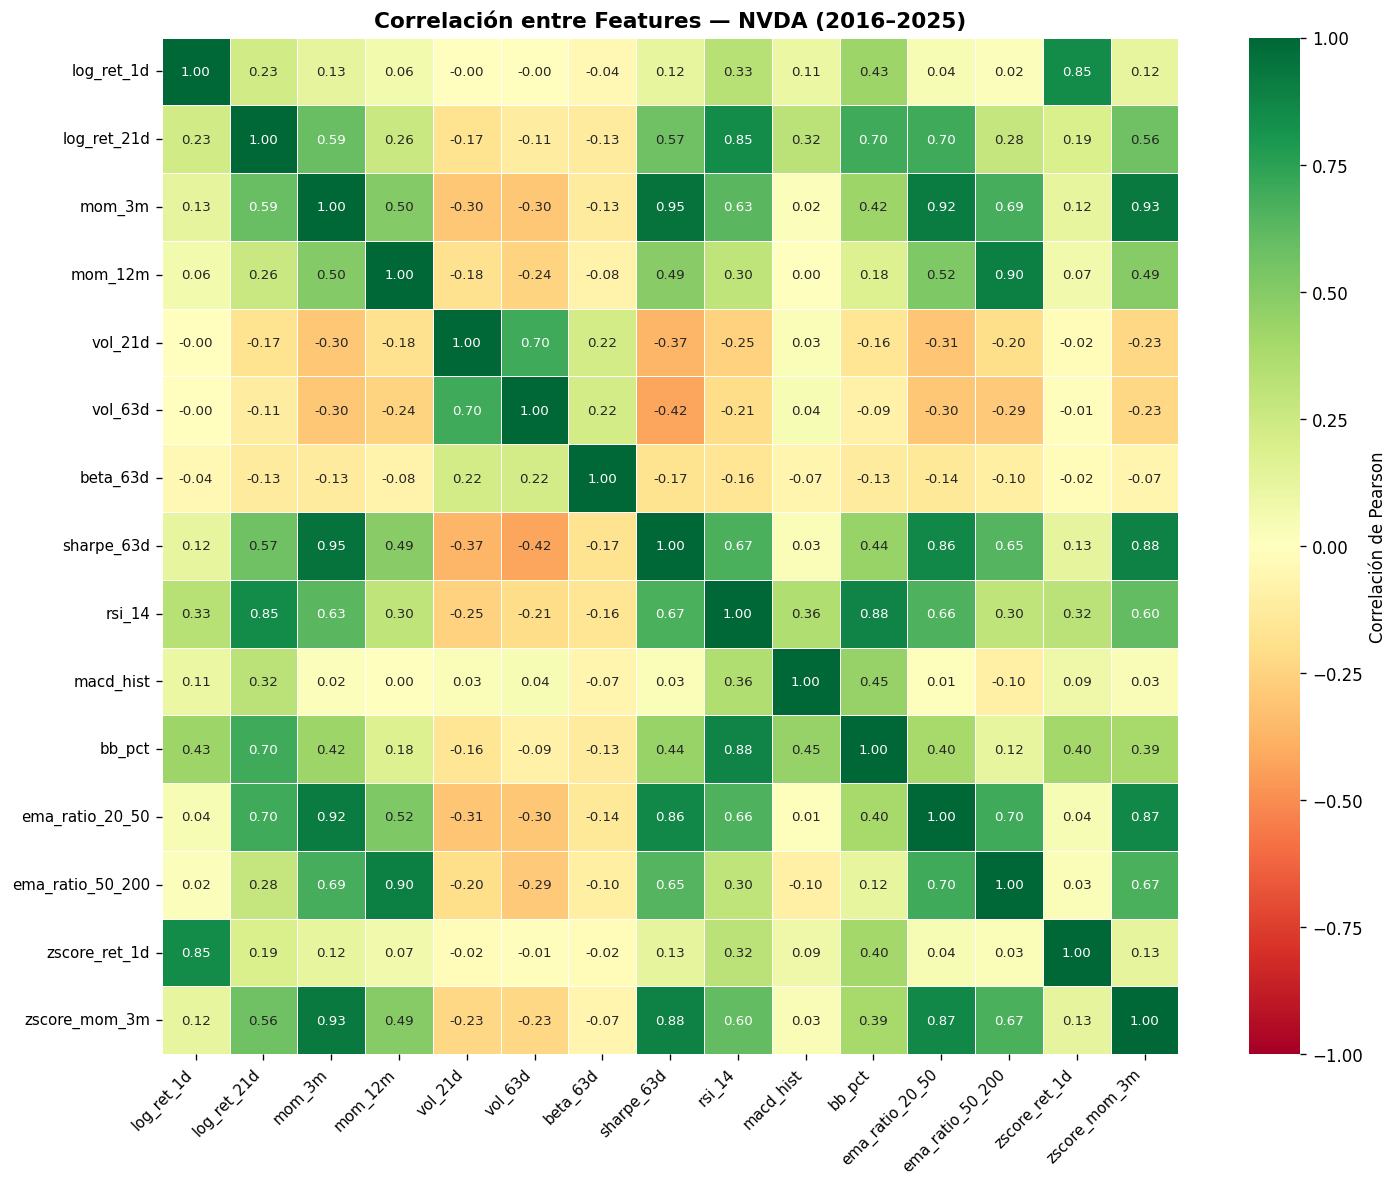

In [10]:
# ── Correlación entre features para NVDA ──────────────────────────────────────
tf_nvda = fe.compute_for_ticker('NVDA').iloc[252:]

# Seleccionar features numéricas
feat_cols = [
    'log_ret_1d', 'log_ret_21d', 'mom_3m', 'mom_12m',
    'vol_21d', 'vol_63d', 'beta_63d', 'sharpe_63d',
    'rsi_14', 'macd_hist', 'bb_pct',
    'ema_ratio_20_50', 'ema_ratio_50_200',
    'zscore_ret_1d', 'zscore_mom_3m',
]
feat_cols = [f for f in feat_cols if f in tf_nvda.columns]

corr_feats = tf_nvda[feat_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_feats, dtype=bool), k=1)
sns.heatmap(
    corr_feats, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.3,
    annot_kws={'size': 8}, ax=ax,
    cbar_kws={'label': 'Correlación de Pearson'},
)
ax.set_title('Correlación entre Features — NVDA (2016–2025)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

---
## 6. Predictibilidad de las Features

Calculamos la correlación de Spearman de cada feature con el retorno futuro a 21 días (información ratio univariada).
Esto da una primera idea de qué features son más informativas para modelos supervisados (Notebook 06).

In [11]:
from scipy.stats import spearmanr

# ── IC (Information Coefficient) de Spearman ─────────────────────────────────
# Para cada feature, calculamos la corr. de Spearman promedio (rolling) 
# con el retorno forward de 21 días en todos los activos del universo

FEATURES_IC = [
    'log_ret_1d', 'mom_1m', 'mom_3m', 'mom_6m', 'mom_12m',
    'vol_21d', 'vol_63d', 'sharpe_63d', 'beta_63d',
    'rsi_14', 'rsi_21', 'macd_hist', 'bb_pct',
    'ema_ratio_20_50', 'ema_ratio_50_200',
    'zscore_ret_1d', 'zscore_mom_3m',
]

# Retornos forward a 21 días para todos los tickers
log_ret = np.log(prices / prices.shift(1))
ret_fwd21 = log_ret.shift(-21).iloc[252:]  # shift negativo = retorno futuro

ic_results = {}
for feat in FEATURES_IC:
    if feat not in features_clean.columns.get_level_values(0):
        continue
    # Extraer feature para todos los tickers
    feat_df = features_clean[feat]
    common_cols = [c for c in feat_df.columns if c in ret_fwd21.columns and c != BENCHMARK]
    if not common_cols:
        continue
    feat_sub = feat_df[common_cols]
    fwd_sub  = ret_fwd21[common_cols]

    # IC por fecha: Spearman entre feature_i y retorno_fwd_i en todos los activos
    ics = []
    for date in feat_sub.index[:-21]:
        f_row = feat_sub.loc[date].dropna()
        r_row = fwd_sub.loc[date].dropna()
        common = f_row.index.intersection(r_row.index)
        if len(common) < 5:
            continue
        rho, _ = spearmanr(f_row[common], r_row[common])
        if not np.isnan(rho):
            ics.append(rho)

    ic_results[feat] = {
        'IC_mean':  np.mean(ics),
        'IC_std':   np.std(ics),
        'ICIR':     np.mean(ics) / np.std(ics) if np.std(ics) > 0 else 0,
        'IC_pct_pos': np.mean(np.array(ics) > 0) * 100,
    }

df_ic = pd.DataFrame(ic_results).T.sort_values('ICIR', ascending=False)
print('Information Coefficient (Spearman) vs Retorno Fwd 21d:')
print(df_ic.round(4).to_string())

Information Coefficient (Spearman) vs Retorno Fwd 21d:
                  IC_mean  IC_std    ICIR  IC_pct_pos
beta_63d           0.0200  0.3944  0.0507     52.5346
ema_ratio_50_200   0.0153  0.3153  0.0485     52.4927
vol_63d            0.0164  0.3463  0.0473     52.5346
vol_21d            0.0152  0.3248  0.0467     52.6602
mom_6m             0.0122  0.2970  0.0409     52.7859
mom_12m            0.0104  0.3139  0.0333     52.2832
ema_ratio_20_50    0.0043  0.2886  0.0148     51.5710
zscore_mom_3m      0.0039  0.2865  0.0137     51.9062
mom_3m             0.0039  0.2865  0.0137     51.9062
sharpe_63d         0.0017  0.2662  0.0063     50.8588
zscore_ret_1d      0.0006  0.2590  0.0021     49.5182
log_ret_1d         0.0006  0.2590  0.0021     49.5182
rsi_21            -0.0035  0.2576 -0.0135     49.1831
bb_pct            -0.0049  0.2415 -0.0202     49.4344
rsi_14            -0.0052  0.2532 -0.0207     49.7696
mom_1m            -0.0063  0.2618 -0.0242     49.7277
macd_hist         -0.0064  

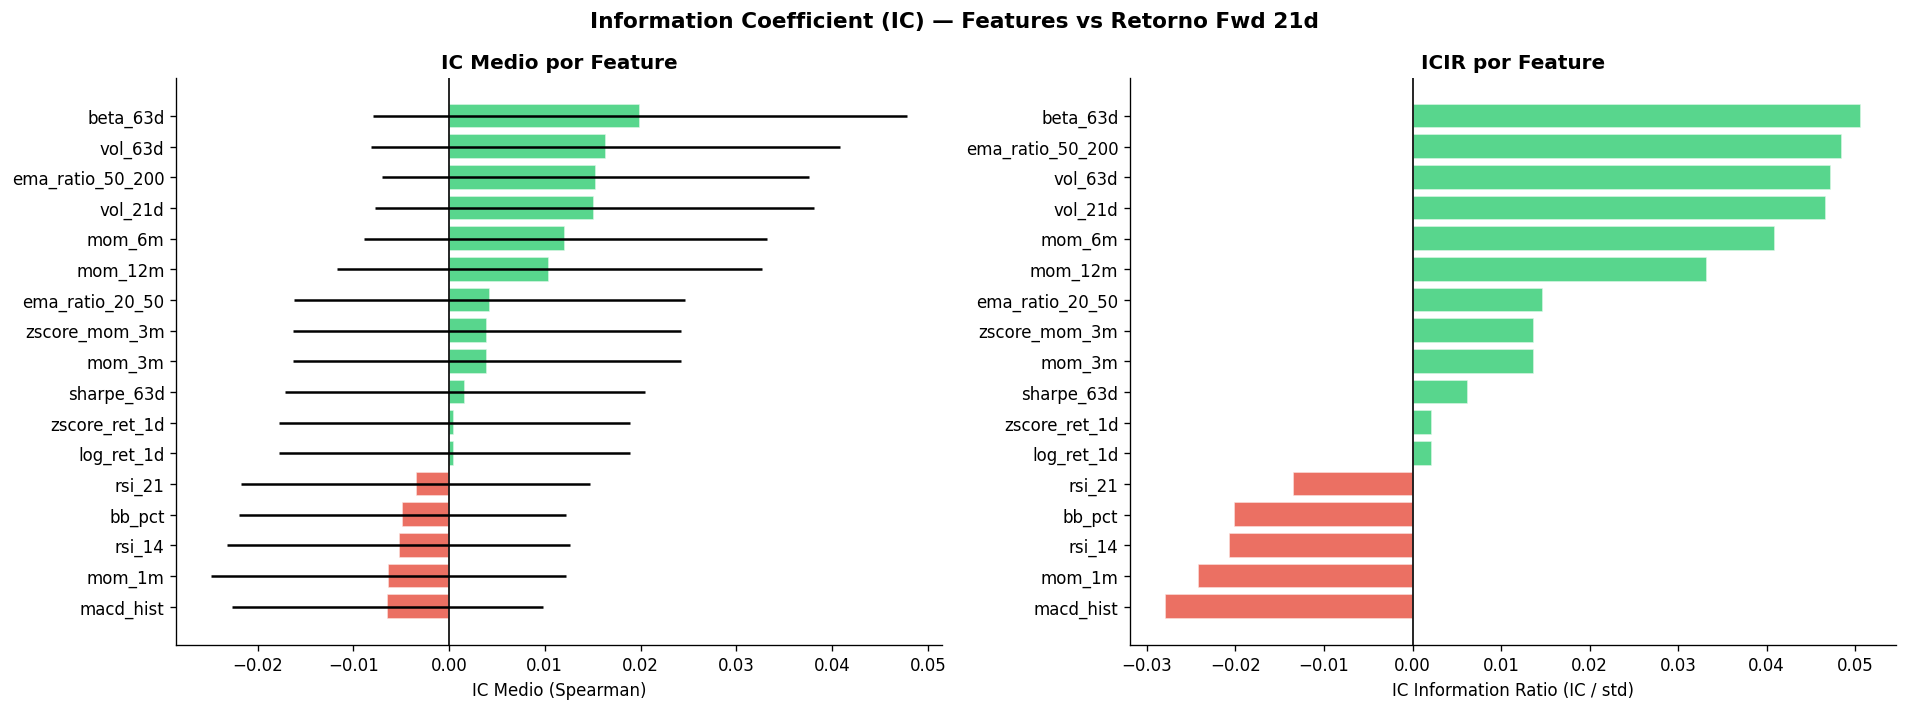

In [12]:
# ── Gráfico de IC por feature ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Information Coefficient (IC) — Features vs Retorno Fwd 21d',
             fontsize=13, fontweight='bold')

# IC medio
df_ic_sorted = df_ic.sort_values('IC_mean')
colors_ic = ['#2ECC71' if v > 0 else '#E74C3C' for v in df_ic_sorted['IC_mean']]
bars = ax1.barh(df_ic_sorted.index, df_ic_sorted['IC_mean'],
                xerr=df_ic_sorted['IC_std'] / np.sqrt(200),
                color=colors_ic, alpha=0.8, edgecolor='white')
ax1.axvline(0, color='black', lw=1)
ax1.set_xlabel('IC Medio (Spearman)')
ax1.set_title('IC Medio por Feature', fontweight='bold')

# ICIR
df_ic_sorted2 = df_ic.sort_values('ICIR')
colors_icir = ['#2ECC71' if v > 0 else '#E74C3C' for v in df_ic_sorted2['ICIR']]
ax2.barh(df_ic_sorted2.index, df_ic_sorted2['ICIR'],
         color=colors_icir, alpha=0.8, edgecolor='white')
ax2.axvline(0, color='black', lw=1)
ax2.set_xlabel('IC Information Ratio (IC / std)')
ax2.set_title('ICIR por Feature', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 7. Estadísticas Descriptivas por Sector

Resumen estadístico de las features de volatilidad y riesgo para cada sector.

In [13]:
# ── Tabla: mediana de features clave por sector ────────────────────────────────
FEATS_RESUMEN = ['vol_21d', 'vol_63d', 'sharpe_63d', 'beta_63d', 'mom_12m', 'rsi_14']

resumen_sector = {}
for sector, tickers in REPRES.items():
    vals = {}
    for feat in FEATS_RESUMEN:
        if feat not in features_clean.columns.get_level_values(0):
            continue
        data_list = []
        for t in tickers:
            if t in features_clean[feat].columns:
                data_list.append(features_clean[feat][t].dropna())
        if data_list:
            combined = pd.concat(data_list)
            vals[feat] = combined.median()
    resumen_sector[sector] = vals

df_resumen_sector = pd.DataFrame(resumen_sector).T
print('═' * 80)
print('MEDIANA DE FEATURES POR SECTOR GICS (período 2016–2025)')
print('═' * 80)
display(df_resumen_sector.round(4))
print('═' * 80)

════════════════════════════════════════════════════════════════════════════════
MEDIANA DE FEATURES POR SECTOR GICS (período 2016–2025)
════════════════════════════════════════════════════════════════════════════════


,vol_21d,vol_63d,sharpe_63d,beta_63d,mom_12m,rsi_14
Information Technology,0.2942,0.3148,0.9214,1.3406,0.2484,54.5741
Consumer Staples,0.1678,0.1819,0.6290,0.4587,0.0979,53.3802
Health Care,0.1994,0.2166,0.6480,0.6684,0.1237,53.1451
Consumer Discretionary,0.2413,0.2565,0.6521,0.9961,0.1319,53.2038


════════════════════════════════════════════════════════════════════════════════


---
## 8. Guardado de Resultados

In [14]:
# ── Guardar precios y features en Parquet ─────────────────────────────────────
os.makedirs('../data/processed', exist_ok=True)

# Precios post warm-up
prices_clean.to_parquet(PRICES_PATH)
print(f'✓ Precios guardados en: {PRICES_PATH}')
print(f'  Shape: {prices_clean.shape}')

# Features (MultiIndex de columnas)
# Aplanar el MultiIndex para compatibilidad máxima con Parquet
features_flat = features_clean.copy()
features_flat.columns = ['__'.join(col) for col in features_flat.columns]
features_flat.to_parquet(FEATURES_PATH)
print(f'\n✓ Features guardadas en: {FEATURES_PATH}')
print(f'  Shape: {features_flat.shape}')
print(f'  Columnas (muestra): {list(features_flat.columns[:6])}...')

✓ Precios guardados en: ../data/processed/prices_repr.parquet
  Shape: (2408, 41)

✓ Features guardadas en: ../data/processed/features.parquet
  Shape: (2408, 902)
  Columnas (muestra): ['log_ret_1d__AAPL', 'log_ret_1d__MSFT', 'log_ret_1d__NVDA', 'log_ret_1d__AVGO', 'log_ret_1d__CSCO', 'log_ret_1d__CRM']...


---
## 9. Conclusiones

### Hallazgos de Ingeniería de Variables

| Feature | Hallazgo | Implicación |
|---------|----------|-------------|
| `vol_21d` | IT tiene volatilidad ~2× mayor que Consumer Staples | Restricción de peso máximo en IT |
| `beta_63d` | IT y Consumer Discretionary tienen β > 1 consistentemente | Exposición al mercado mayor que SPY |
| `sharpe_63d` | Alta dispersión — signals de timing útiles | Feature relevante para selección activa |
| `mom_3m/12m` | Persistencia del momentum en IT (NVDA, MSFT) | Factor momentum válido para ML |
| `rsi_14` | Sobrecompra frecuente en IT durante 2023-2025 (RSI > 70) | Señal de mean-reversion táctica |
| ICIR | `mom_3m`, `sharpe_63d`, `ema_ratio` tienen ICIR > 0.1 | Features prioritarias para modelos supervisados |

### Siguientes Pasos

- **Notebook 03**: Modelo base Markowitz (frontera eficiente) usando estas features
- **Notebook 04**: Modelado GARCH para volatilidad condicional
- **Notebook 06**: Modelos supervisados usando el IC como guía de selección de features

---
*Feature Engineering completado — Estancia de Investigación en Finanzas Cuantitativas, AD2026.*